In [181]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
import sys
import json
import pickle
from datetime import datetime, timedelta

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

print(f"Added to path: {current_dir}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka


In [182]:


# Set your directory and seed
directory = "data_w_diff_001"
seed_value = 53

all_files = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
random.seed(seed_value)
random_df_filepaths = random.sample(all_files, 1)


In [183]:
from test.kf_wrls_seasonal_lags import KalmanFilterWRLSEstimatorSeasonalLags
from test.kf_seasonal_lags import WaterMeterKalmanFilterSeasonalLags
from test.kf_metrics import evaluate_kalman_filter, KalmanFilterMetrics

from test.kf_wrls_estimator import KalmanFilterWRLSEstimator
from test.kf import WaterMeterKalmanFilter


def get_KF_model_seasonal(df, expected_interval_seconds, tolerance_percent = 10.0, lambda_forget=0.9999):
    estimator = KalmanFilterWRLSEstimatorSeasonalLags(lambda_forget=lambda_forget)

    A, Q, R, metadata = estimator.estimate_from_dataframe(
        df,
        expected_interval_seconds=expected_interval_seconds,
        tolerance_percent=tolerance_percent,
        verbose=False
    )

    return A, Q, R, metadata

def get_KF_model_fourier(df, expected_interval_seconds, tolerance_percent = 10.0, n_harmonics=3, lambda_forget=0.9999):
    estimator = KalmanFilterWRLSEstimator(lambda_forget=lambda_forget)

    A, Q, R, metadata = estimator.estimate_from_dataframe(
        df,
        expected_interval_seconds=expected_interval_seconds,
        n_harmonics=n_harmonics,
        tolerance_percent=tolerance_percent,
        verbose=False
    )

    return A, Q, R, metadata

In [184]:
estimator_metadatas_fourier = {}
all_metrics_fourier = {}
skipped_files_small_period = []
skipped_files_error = []
metadata_dir = './metadata_001'
df_dir = './data_w_diff_001'


for file in random_df_filepaths:
    print(f"Loading file: {file}")
    df_filepath = os.path.join(df_dir, file)
    metadata_filepath = os.path.join(metadata_dir, file.split('.')[0] + '.json')
    
    df = pd.read_csv(df_filepath)
    
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    mask = df['timestamp'] >= pd.to_datetime('2024-09-01')
    df = df.loc[mask]

    with open(metadata_filepath) as f:
        metadata_file = json.load(f)

    end = datetime.fromisoformat(metadata_file['end_time'])

    if (end - pd.to_datetime('2024-09-01')) < timedelta(days=365):
        skipped_files_small_period.append(file)
        print("Skipping file: Too short timestamp")
        continue
    
    if metadata_file['common_periodicity_seconds'] > 12*60*60:
        skipped_files_small_period.append(file)
        print("Skipping file: Too long periodicity")
        continue
    
    try:
        A, Q, R, metadata_estimator = get_KF_model_fourier(df, expected_interval_seconds=metadata_file['common_periodicity_seconds'])
    except Exception as e:
        skipped_files_error.append(file)
        print(f"Error {e} occured when estimating file: {file}.")
        continue
        
    estimator_metadatas_fourier[file] = metadata_estimator
    kf = WaterMeterKalmanFilter(A, Q, R, n_harmonics=3, seasonal_period=24.0)
    
        
    try:
        df_filtered = kf.filter_dataframe(
            df,
            anomaly_threshold=3.0,
            return_diagnostics=True
        )
    except Exception as e:
        skipped_files_error.append(file)
        print(f"Error {e} occured when filtering file: {file}.")
        continue

    df_filtered = df_filtered[48*10:]

    all_metrics_fourier[file] = KalmanFilterMetrics.compute_all_metrics(
        df_filtered,
        nonzero_threshold=0.01
    )

Loading file: 148714.csv


In [185]:
estimator_metadatas_seasonal_lags = {}
all_metrics_seasonal_lags = {}
metadata_dir = './metadata_001'
df_dir = './data_w_diff_001'


for file in random_df_filepaths:
    print(f"Loading file: {file}")
    df_filepath = os.path.join(df_dir, file)
    metadata_filepath = os.path.join(metadata_dir, file.split('.')[0] + '.json')
    
    df = pd.read_csv(df_filepath)
    
    with open(metadata_filepath) as f:
        metadata_file = json.load(f)
        
    start = datetime.fromisoformat(metadata_file['start_time'])
    end = datetime.fromisoformat(metadata_file['end_time'])

    if (end - start) < timedelta(days=365):
        continue
    
    if metadata_file['common_periodicity_seconds'] > 12*60*60:
        print("Skipping file: Too long periodicity")
        continue
    
    A, Q, R, metadata_estimator = get_KF_model_seasonal(df, expected_interval_seconds=metadata_file['common_periodicity_seconds'])
    estimator_metadatas_seasonal_lags[file] = metadata_estimator
    
    kf = WaterMeterKalmanFilterSeasonalLags(A, Q, R)
    
    df_filtered = kf.filter_dataframe(
        df,
        anomaly_threshold=3.0,
        return_diagnostics=True
    )

    df_filtered = df_filtered[48*10:]

    all_metrics_seasonal_lags[file] = KalmanFilterMetrics.compute_all_metrics(
        df_filtered,
        nonzero_threshold=0.01
    )

Loading file: 148714.csv


In [186]:
all_metrics_seasonal_lags

{}

In [187]:
estimator_metadatas_seasonal_lags

{}

In [188]:
def get_mean_values(metric: str, fourier_metadatas: dict, seasonal_metadatas: dict, extreme_value=1000, nonzero:bool=True, verbose: bool=True):
    fourier_values = [v[metric] for v in fourier_metadatas.values() if metric in v.keys() and abs(v[metric]) < abs(extreme_value)]
    seasonal_values = [v[metric] for v in seasonal_metadatas.values() if metric in v.keys() and abs(v[metric]) < abs(extreme_value)]
    fourier_mean = np.nanmean(fourier_values)
    seasonal_mean = np.nanmean(seasonal_values)
    fourier_std = np.nanstd(fourier_values)
    seasonal_std = np.nanstd(seasonal_values)
    
    if nonzero:
        fourier_values_nonzero = [v[f"{metric}_nonzero"] for v in fourier_metadatas.values() if f"{metric}_nonzero" in v.keys() and abs(v[f"{metric}_nonzero"]) < abs(extreme_value)]
        seasonal_values_nonzero = [v[f"{metric}_nonzero"] for v in seasonal_metadatas.values() if f"{metric}_nonzero" in v.keys() and abs(v[f"{metric}_nonzero"]) < abs(extreme_value)]
        fourier_mean_nonzero = np.nanmean(fourier_values_nonzero)
        seasonal_mean_nonzero = np.nanmean(seasonal_values_nonzero)
        fourier_std_nonzero = np.nanstd(fourier_values_nonzero)
        seasonal_std_nonzero = np.nanstd(seasonal_values_nonzero)

    
    if verbose:
        print(f"Fourier {metric}:\nMean: {fourier_mean} with Std: {fourier_std}.\n")
        print(f"Seasonal {metric}:\nMean: {seasonal_mean} with Std: {seasonal_std}.\n")
        if nonzero:
            print(f"Fourier Nonzero {metric}:\nMean {fourier_mean_nonzero} with Std: {fourier_std_nonzero}.\n")
            print(f"Seasonal Nonzero {metric}:\nMean {seasonal_mean_nonzero} with Std: {seasonal_std_nonzero}.\n")
    
    if nonzero:
        return fourier_mean, fourier_std, seasonal_mean, seasonal_std, fourier_mean_nonzero, fourier_std_nonzero, seasonal_mean_nonzero, seasonal_std_nonzero
    
    return fourier_mean, fourier_std, seasonal_mean, seasonal_std

In [189]:
def print_histograms(metric: str, fourier_metadatas: dict, seasonal_metadatas: dict, extreme_value=1000, nonzero:bool = True):
    
    fourier_values = [v[metric] for v in fourier_metadatas.values() if metric in v.keys() and abs(v[metric]) < abs(extreme_value)]
    seasonal_values = [v[metric] for v in seasonal_metadatas.values() if v[metric] if metric in v.keys() and abs(v[metric]) < abs(extreme_value)]
    
    if nonzero:
        fourier_values_nonzero = [v[f"{metric}_nonzero"] for v in fourier_metadatas.values() if f"{metric}_nonzero" in v.keys() and abs(v[f"{metric}_nonzero"]) < abs(extreme_value)]
        seasonal_values_nonzero = [v[f"{metric}_nonzero"] for v in seasonal_metadatas.values() if f"{metric}_nonzero" in v.keys() and abs(v[f"{metric}_nonzero"]) < abs(extreme_value)]
        fig, axs = plt.subplots(4, sharex=True, figsize=(6, 10))
    else:
        fig, axs = plt.subplots(2, sharex=True, figsize=(6, 10))
        
    fig.suptitle(f"Histogram of {metric} Across Files")
    bins = 20

    # First subplot: Fourier histogram
    axs[0].hist(fourier_values, bins=bins, color='skyblue', alpha=0.6, edgecolor='black', label='All values')
    axs[0].set_title('Fourier Metrics')
    axs[0].set_ylabel('Count')
    axs[0].legend()

    # Second subplot: Seasonal histogram
    axs[1].hist(seasonal_values, bins=bins, color='orange', alpha=0.6, edgecolor='black', label='All values')
    axs[1].set_title('Seasonal Metrics')
    axs[1].set_xlabel(metric)
    axs[1].set_ylabel('Count')
    axs[1].legend()
    
    if not nonzero:
        plt.tight_layout()
        plt.show()
        return
    
    # Third subplot: Fourier histogram nonzero
    axs[2].hist(fourier_values_nonzero, bins=bins, color='darkblue', alpha=0.6, edgecolor='black', label='Nonzero values')
    axs[2].set_title('Fourier Metrics Nonzero')
    axs[2].set_ylabel('Count')
    axs[2].legend()

    # Second subplot: Seasonal histogram nonzero
    axs[3].hist(seasonal_values_nonzero, bins=bins, color='darkorange', alpha=0.6, edgecolor='black', label='Nonzero values')
    axs[3].set_title('Seasonal Metrics Nonzero')
    axs[3].set_xlabel(metric)
    axs[3].set_ylabel('Count')
    axs[3].legend()

    plt.tight_layout()
    plt.show()


In [190]:
with open('results_A_comparison/all_metrics_fourier.pkl', 'rb') as pkl_file:
    all_metrics_fourier = pickle.load(pkl_file)
with open('results_A_comparison/all_metrics_seasonal.pkl', 'rb') as pkl_file:
    all_metrics_seasonal = pickle.load(pkl_file)
with open('results_A_comparison/estimator_metadatas_fourier.pkl', 'rb') as pkl_file:
    estimator_metadatas_fourier = pickle.load(pkl_file)
with open('results_A_comparison/estimator_metadatas_seasonal.pkl', 'rb') as pkl_file:
    estimator_metadatas_seasonal = pickle.load(pkl_file)

In [191]:
print(len(all_metrics_fourier))
print(len(all_metrics_seasonal))
print(len(estimator_metadatas_fourier))
print(len(estimator_metadatas_seasonal))

816
192
816
192


## Prediction Metrics

### R^2

In [192]:
get_mean_values('R2_prediction', all_metrics_fourier, all_metrics_seasonal, extreme_value=10, verbose=True)

Fourier R2_prediction:
Mean: 0.030403955031415294 with Std: 0.3664102037772905.

Seasonal R2_prediction:
Mean: 0.19797481385733778 with Std: 0.31461777057467255.

Fourier Nonzero R2_prediction:
Mean -0.7634131236040539 with Std: 1.4908513629866404.

Seasonal Nonzero R2_prediction:
Mean -0.29955153887946556 with Std: 1.112321105510598.



(0.030403955031415294,
 0.3664102037772905,
 0.19797481385733778,
 0.31461777057467255,
 -0.7634131236040539,
 1.4908513629866404,
 -0.29955153887946556,
 1.112321105510598)

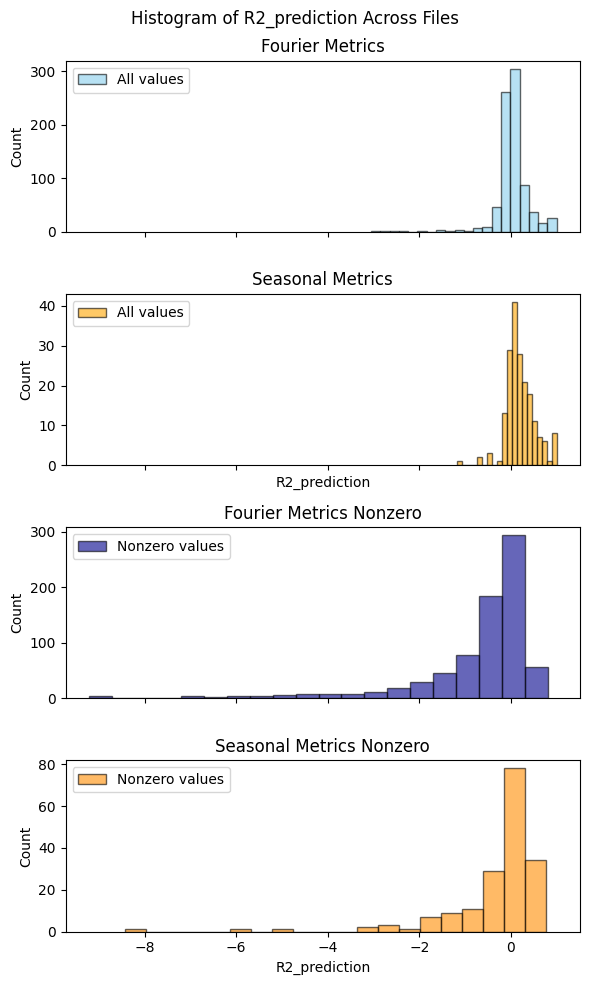

In [193]:
print_histograms('R2_prediction', all_metrics_fourier, all_metrics_seasonal, extreme_value=10)

### MAE

In [194]:
seasonal_vals = [v['MAE_prediction'] for v in all_metrics_seasonal.values() if 'MAE_prediction' in v.keys()]

for val in seasonal_vals:
    if val > 10:
        print(val)

123.46173091817518
48.17217273484974


In [195]:
get_mean_values('MAE_prediction', all_metrics_fourier, all_metrics_seasonal, extreme_value=10)

Fourier MAE_prediction:
Mean: 0.1203948641616067 with Std: 0.4308825910327598.

Seasonal MAE_prediction:
Mean: 0.13817787595654038 with Std: 0.7303650404355452.

Fourier Nonzero MAE_prediction:
Mean 0.17501682700300186 with Std: 0.4721782342890443.

Seasonal Nonzero MAE_prediction:
Mean 0.18980139180536026 with Std: 0.8112224212258592.



(0.1203948641616067,
 0.4308825910327598,
 0.13817787595654038,
 0.7303650404355452,
 0.17501682700300186,
 0.4721782342890443,
 0.18980139180536026,
 0.8112224212258592)

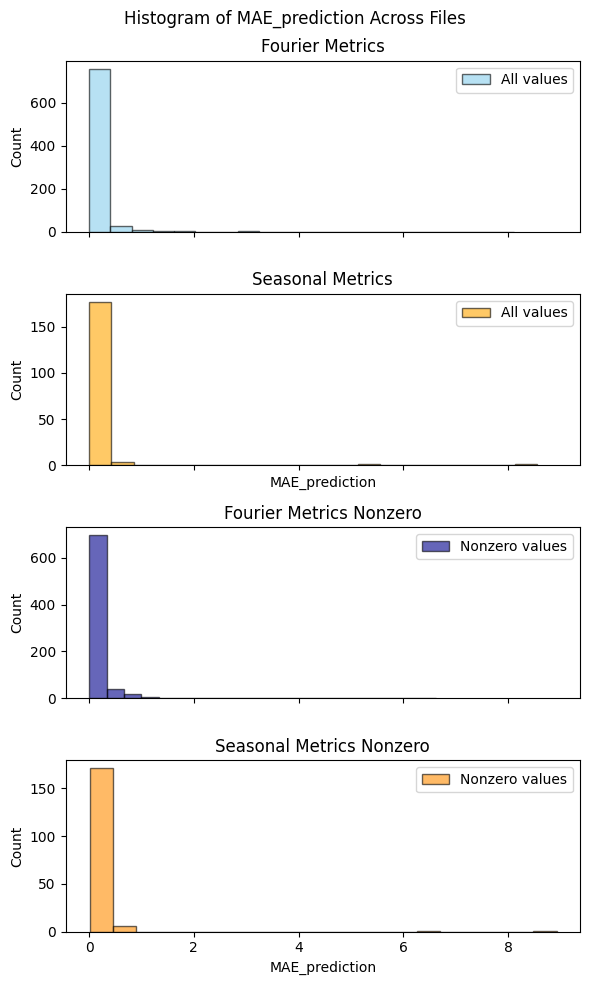

In [196]:
print_histograms('MAE_prediction', all_metrics_fourier, all_metrics_seasonal, extreme_value=10)

### RMSE

In [197]:
get_mean_values('RMSE_prediction', all_metrics_fourier, all_metrics_seasonal, extreme_value=50)

Fourier RMSE_prediction:
Mean: 0.4108447011619406 with Std: 2.2127003122160263.

Seasonal RMSE_prediction:
Mean: 0.4181234686361485 with Std: 1.7558355296209396.

Fourier Nonzero RMSE_prediction:
Mean 0.47167342563355746 with Std: 2.1303114250344586.

Seasonal Nonzero RMSE_prediction:
Mean 0.6253407819305236 with Std: 2.648089198975695.



(0.4108447011619406,
 2.2127003122160263,
 0.4181234686361485,
 1.7558355296209396,
 0.47167342563355746,
 2.1303114250344586,
 0.6253407819305236,
 2.648089198975695)

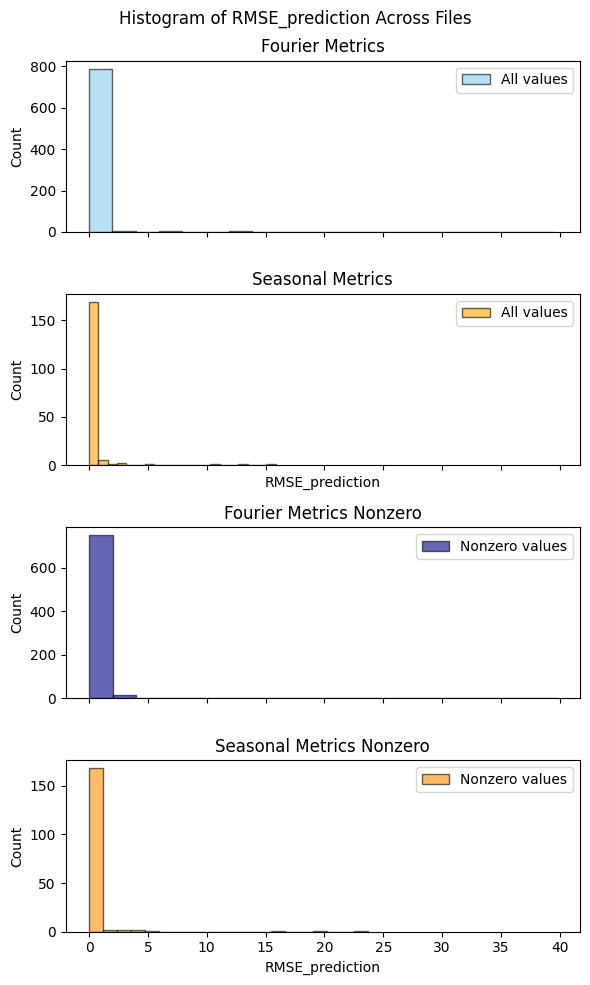

In [198]:
print_histograms('RMSE_prediction', all_metrics_fourier, all_metrics_seasonal, extreme_value=50)

### Validity Percantage

In [199]:
get_mean_values('validity_percentage', estimator_metadatas_fourier, estimator_metadatas_seasonal, nonzero=False)

Fourier validity_percentage:
Mean: 81.42436227352596 with Std: 19.63390518494351.

Seasonal validity_percentage:
Mean: 49.89223414351877 with Std: 32.743203069944414.



(81.42436227352596, 19.63390518494351, 49.89223414351877, 32.743203069944414)

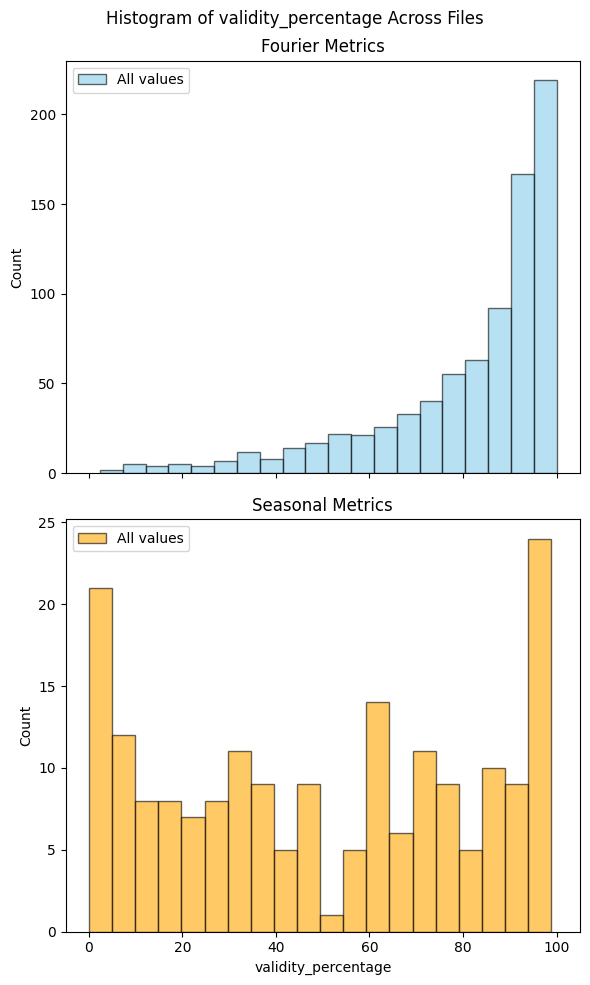

In [200]:
print_histograms('validity_percentage', estimator_metadatas_fourier, estimator_metadatas_seasonal, nonzero=False)

## Filtered Metrics

### MAE

In [201]:
get_mean_values('MAE_filtered', all_metrics_fourier, all_metrics_seasonal, extreme_value=10)

Fourier MAE_filtered:
Mean: 0.05346456857529811 with Std: 0.29819190353329555.

Seasonal MAE_filtered:
Mean: 0.08531310887653588 with Std: 0.5579535792549641.

Fourier Nonzero MAE_filtered:
Mean 0.09437358204514194 with Std: 0.5652584263241758.

Seasonal Nonzero MAE_filtered:
Mean 0.11132479581014022 with Std: 0.6131682215887588.



(0.05346456857529811,
 0.29819190353329555,
 0.08531310887653588,
 0.5579535792549641,
 0.09437358204514194,
 0.5652584263241758,
 0.11132479581014022,
 0.6131682215887588)

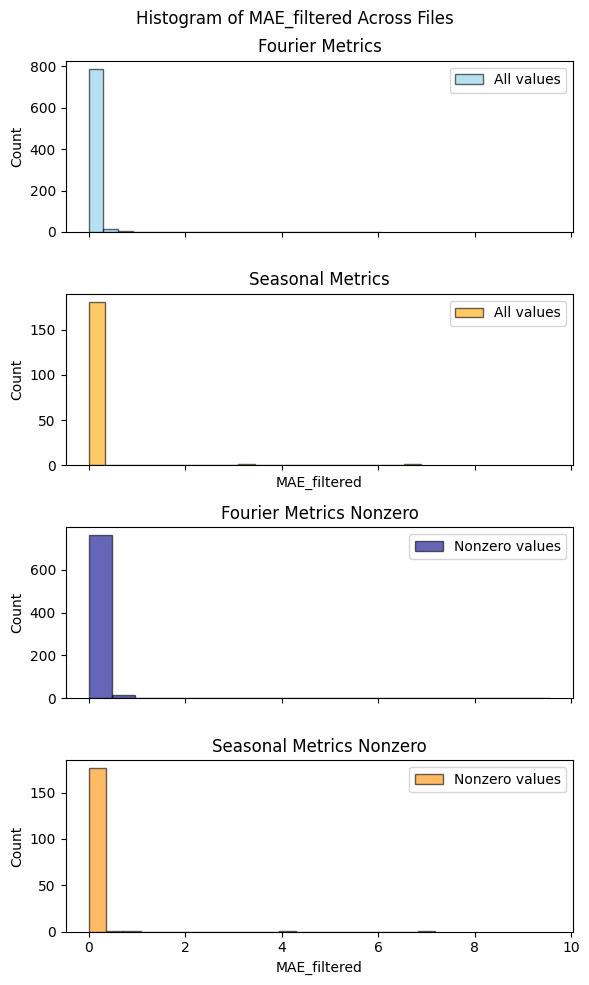

In [202]:
print_histograms('MAE_filtered', all_metrics_fourier, all_metrics_seasonal, extreme_value=10)

### RMSE

In [203]:
get_mean_values('RMSE_filtered', all_metrics_fourier, all_metrics_seasonal, extreme_value=50)

Fourier RMSE_filtered:
Mean: 0.2150592215776303 with Std: 1.6364618710089913.

Seasonal RMSE_filtered:
Mean: 0.2262933253032075 with Std: 1.2360640449830107.

Fourier Nonzero RMSE_filtered:
Mean 0.23106826114883602 with Std: 1.4668534194271274.

Seasonal Nonzero RMSE_filtered:
Mean 0.3547063550974611 with Std: 2.0451900112421115.



(0.2150592215776303,
 1.6364618710089913,
 0.2262933253032075,
 1.2360640449830107,
 0.23106826114883602,
 1.4668534194271274,
 0.3547063550974611,
 2.0451900112421115)

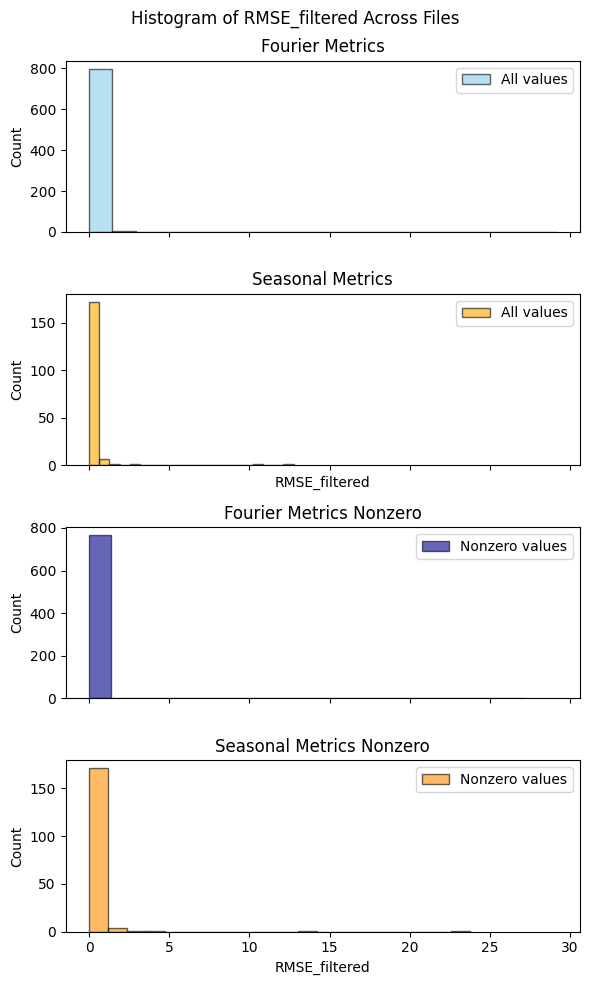

In [204]:
print_histograms('RMSE_filtered', all_metrics_fourier, all_metrics_seasonal, extreme_value=50)

In [ ]:
files_high_validity = [k for k in estimator_metadatas_seasonal.keys() if estimator_metadatas_seasonal[k]['validity_percentage'] > 70]
print(files_high_validity)
all_metrics_fourier_high_val = [(k,v) for k,v in all_metrics_fourier.items() if k in files_high_validity]
print(len(all_metrics_fourier_high_val))

SyntaxError: did you forget parentheses around the comprehension target? (128459237.py, line 3)